In [1]:
import os
import math
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

# The Groq API key is loaded from .env via GROQ_API_KEY.
# Do not store the secret directly in this notebook.

C:\Users\visarati\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
class State(TypedDict):
    input: str
    output: str

In [4]:
def function1(state):
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke(state["input"]).content
    return {"output": response}

In [5]:
def function2(state):
    return {"output": state["output"].upper()}

In [6]:
workflow = StateGraph(State)

In [7]:
workflow.add_node("llm", function1)
workflow.add_node("upper_string", function2)


In [8]:
workflow.add_edge(START, "llm")
workflow.add_edge("llm", "upper_string")
workflow.add_edge("upper_string", END)

In [9]:
app = workflow.compile()

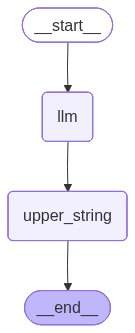

In [10]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [11]:
app.invoke({"input": "what is the name of the first Indian prime minister?"})


{'input': 'what is the name of the first Indian prime minister?',
 'output': 'THE FIRST INDIAN PRIME MINISTER WAS JAWAHARLAL NEHRU.'}